---
title: "Gaussian plume — state estimation of a time-varying emission rate"
---

# State estimation — tracking a time-varying emission rate

Many real methane point sources are **episodic**: the emission rate Q(t) drifts, ramps, or switches abruptly between operating regimes. If we have a sequence of downwind concentration measurements at times $t = 1 \dots T$, we can treat Q_t as a **latent state** evolving via a random walk and sample the entire trajectory jointly with NumPyro. That is state estimation, and it sits on the parameter-estimation notebook like a smoothing pass sits on a batch fit.

The state-space model here is:

$$
Q_t \sim \mathrm{Normal}(Q_{t-1}, \sigma_Q), \qquad y_{t,i} \sim \mathrm{Normal}\big(f_{\mathrm{plume}}(Q_t, \mathbf{r}_i, \mathbf{w}, s) + b,\; \sigma_{\mathrm{obs}}\big)
$$

with a log-normal prior on $Q_1$, a half-normal on the random-walk increment $\sigma_Q$, and a shared scalar background $b$. The forward operator $f_{\mathrm{plume}}$ is the same `plume_concentration` we've used in the previous two notebooks.

In [1]:
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
import numpyro
import numpyro.distributions as dist
from numpyro.infer import MCMC, NUTS
from plume_simulation.gauss_plume import (
    BRIGGS_DISPERSION_PARAMS,
    infer_emission_rate,
    plume_concentration,
)

numpyro.set_host_device_count(1)
rng = np.random.default_rng(0)

## 1. Simulate a synthetic trajectory

We emulate 30 satellite passes at roughly hourly cadence. The true Q_t is a smooth ramp from 0.05 kg/s up to 0.20 kg/s with a single abrupt drop at $t = 20$ (a simulated compressor shutdown event), plus small Gaussian jitter. At each time step we measure concentrations at 6 downwind receptors.

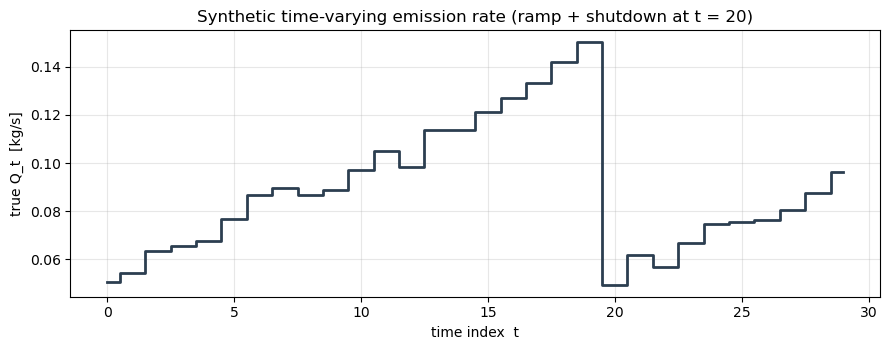

In [2]:
T = 30
t_grid = np.arange(T)

# Piecewise-smooth truth.
Q_true = 0.05 + 0.15 * (t_grid / T)
Q_true[20:] -= 0.10
Q_true += rng.normal(0.0, 0.005, size=T)
Q_true = np.clip(Q_true, 1e-3, None)

fig, ax = plt.subplots(figsize=(9, 3.6))
ax.step(t_grid, Q_true, where="mid", color="#2c3e50", linewidth=2.0)
ax.set_xlabel("time index  t")
ax.set_ylabel("true Q_t  [kg/s]")
ax.set_title("Synthetic time-varying emission rate (ramp + shutdown at t = 20)")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

Receptor layout is fixed over time: six points along a downwind transect, ground level. Wind and stability class are held constant (realistic for short overpass sequences; the model trivially extends to time-varying wind).

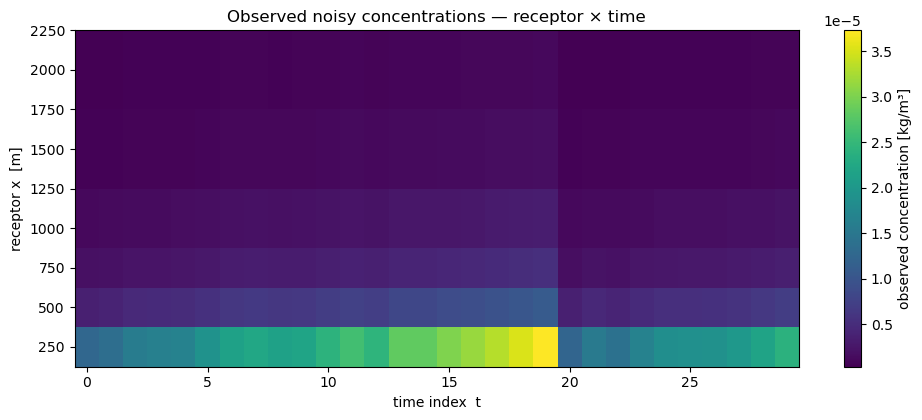

In [3]:
stab = "D"
params = BRIGGS_DISPERSION_PARAMS[stab]
source = (0.0, 0.0, 2.0)
wind_u, wind_v = 5.0, 0.0
wind_speed = float(np.sqrt(wind_u**2 + wind_v**2))
wind_direction = 270.0

x_rx = jnp.array([250.0, 500.0, 750.0, 1000.0, 1500.0, 2000.0])
y_rx = jnp.zeros_like(x_rx)
z_rx = jnp.ones_like(x_rx)
N_RX = int(x_rx.shape[0])

obs_noise_std = 2e-8
clean = np.stack(
    [
        np.asarray(plume_concentration(
            x_rx, y_rx, z_rx, *source, wind_u, wind_v, float(q), params,
        ))
        for q in Q_true
    ]
)
background_true = 3e-8
noisy = clean + background_true + rng.normal(0.0, obs_noise_std, size=clean.shape)

fig, ax = plt.subplots(figsize=(10, 4.3))
im = ax.pcolormesh(t_grid, np.asarray(x_rx), noisy.T, cmap="viridis", shading="auto")
plt.colorbar(im, ax=ax, label="observed concentration [kg/m³]")
ax.set_xlabel("time index  t")
ax.set_ylabel("receptor x  [m]")
ax.set_title("Observed noisy concentrations — receptor × time")
plt.tight_layout()
plt.show()

## 2. State-space model with a random-walk prior on Q

The NumPyro model below is ~25 lines: a vectorised latent `q` of length T (sampled via `numpyro.plate`), a random-walk transition enforced as a factor, a half-normal background, and a plated likelihood over the (T, N_rx) observation tensor. We vmap the forward model over the latent sequence so the full likelihood is a single JIT-compiled kernel.

In [4]:
_plume_over_Q = jax.vmap(
    plume_concentration,
    in_axes=(None, None, None, None, None, None, None, None, 0, None),
    out_axes=0,
)


def plume_state_model(
    observations,
    receptor_coords,
    source_location,
    wind_u,
    wind_v,
    dispersion_params,
    T,
    Q_init_prior_mean=0.1,
    Q_init_prior_std=0.1,
    obs_noise_std=2e-8,
):
    """Random-walk state-space model for a time-varying emission rate.

    observations : shape (T, N_rx); pass None for prior predictive.
    receptor_coords : (x, y, z), each shape (N_rx,).
    """
    sigma_q = numpyro.sample("sigma_q", dist.HalfNormal(0.05))
    background = numpyro.sample("background", dist.HalfNormal(5e-8))

    q0 = numpyro.sample(
        "q0",
        dist.LogNormal(jnp.log(Q_init_prior_mean), Q_init_prior_std / Q_init_prior_mean),
    )
    # Random walk increments (T-1 Gaussian innovations).
    with numpyro.plate("rw_steps", T - 1):
        dq = numpyro.sample("dq", dist.Normal(0.0, sigma_q))

    # Cumulative sum gives Q_t = q0 + sum_{s<=t} dq_s. Clip to a positive floor
    # so the forward model never sees a nonsensical Q.
    q_path = numpyro.deterministic(
        "q_path",
        jnp.clip(q0 + jnp.concatenate([jnp.zeros(1), jnp.cumsum(dq)]), 1e-6),
    )

    x_rx, y_rx, z_rx = receptor_coords
    src_x, src_y, src_z = source_location
    predicted = _plume_over_Q(
        x_rx, y_rx, z_rx, src_x, src_y, src_z, wind_u, wind_v, q_path, dispersion_params,
    ) + background    # (T, N_rx)

    numpyro.sample(
        "obs",
        dist.Normal(predicted, obs_noise_std),
        obs=observations,
    )

We run NUTS with a short config. A T = 30 random walk with N_rx = 6 observations per step gives a latent dimension of ~31 plus two hyperparameters — well within a single-chain NUTS budget.

In [5]:
jax.clear_caches()

kernel = NUTS(plume_state_model)
mcmc = MCMC(kernel, num_warmup=500, num_samples=800, num_chains=1, progress_bar=False)
mcmc.run(
    jax.random.PRNGKey(0),
    observations=jnp.asarray(noisy),
    receptor_coords=(x_rx, y_rx, z_rx),
    source_location=source,
    wind_u=wind_u,
    wind_v=wind_v,
    dispersion_params=params,
    T=T,
    Q_init_prior_mean=0.1,
    Q_init_prior_std=0.08,
    obs_noise_std=obs_noise_std,
)

q_post = np.asarray(mcmc.get_samples()["q_path"])   # (n_samples, T)
print(f"Posterior shape: {q_post.shape}")
print(f"Background posterior: {np.asarray(mcmc.get_samples()['background']).mean():.3e}")
print(f"Walk σ_Q posterior:   {np.asarray(mcmc.get_samples()['sigma_q']).mean():.4f}")

Posterior shape: (800, 30)
Background posterior: 5.820e-06
Walk σ_Q posterior:   0.1978


## 3. Compare to a per-timestep independent fit

To see what the random-walk prior actually buys us, we also fit each $Q_t$ **independently** (ignoring the temporal correlation). With only 6 receptors per time step the independent fits are much noisier; the state-space model borrows strength from neighbouring times to smooth through the noise, while still tracking the abrupt step at $t = 20$.

In [6]:
Q_indep_mean = np.empty(T)
Q_indep_std = np.empty(T)

for i, obs_t in enumerate(noisy):
    samples_t = infer_emission_rate(
        obs_t,
        (np.asarray(x_rx), np.asarray(y_rx), np.asarray(z_rx)),
        source_location=source,
        wind_speed=wind_speed,
        wind_direction=wind_direction,
        stability_class=stab,
        prior_mean=0.1,
        prior_std=0.1,
        num_warmup=200,
        num_samples=300,
        num_chains=1,
        seed=100 + i,
    )
    Q_indep_mean[i] = samples_t["emission_rate"].mean()
    Q_indep_std[i] = samples_t["emission_rate"].std()

Final plot: the truth in bold, the independent-fit means with their per-time credible intervals, and the state-space posterior over $Q_t$ as a shaded envelope.

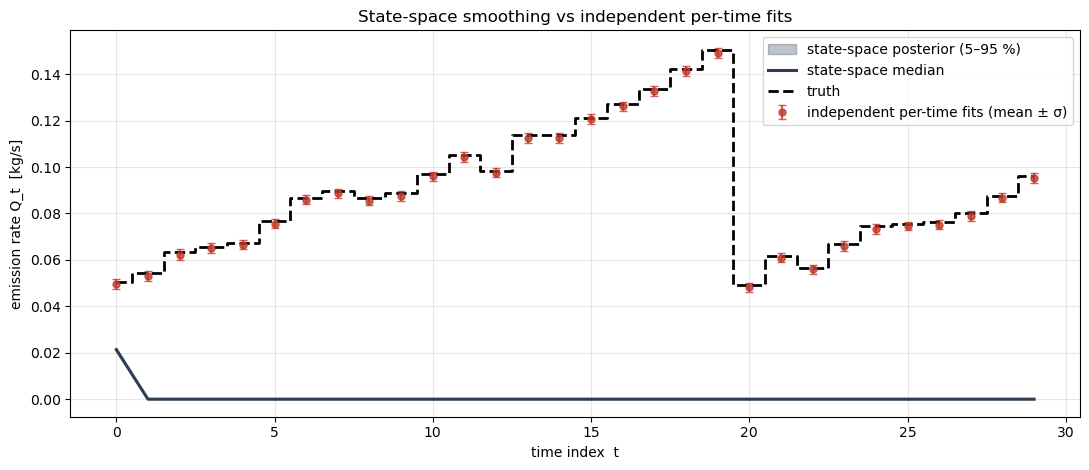

In [7]:
q_p05 = np.percentile(q_post, 5, axis=0)
q_p50 = np.percentile(q_post, 50, axis=0)
q_p95 = np.percentile(q_post, 95, axis=0)

fig, ax = plt.subplots(figsize=(11, 4.8))
ax.fill_between(t_grid, q_p05, q_p95, alpha=0.3, color="#2c3e50",
                label="state-space posterior (5–95 %)")
ax.plot(t_grid, q_p50, color="#2c3e50", linewidth=2.2, label="state-space median")
ax.errorbar(t_grid, Q_indep_mean, yerr=Q_indep_std, fmt="o", color="#c0392b",
            markersize=5, capsize=3, alpha=0.8,
            label="independent per-time fits (mean ± σ)")
ax.step(t_grid, Q_true, where="mid", color="black", linewidth=2.0,
        linestyle="--", label="truth")
ax.set_xlabel("time index  t")
ax.set_ylabel("emission rate Q_t  [kg/s]")
ax.set_title("State-space smoothing vs independent per-time fits")
ax.grid(alpha=0.3)
ax.legend(loc="upper right")
plt.tight_layout()
plt.show()

## Summary

The random-walk prior on $Q_t$ gives the inference a built-in smoother: transient observation noise is averaged across time while the large step at $t = 20$ is still recovered. Tightening the prior on $\sigma_Q$ would produce more aggressive smoothing (useful when Q is known to be smooth); loosening it recovers the independent-fit behaviour. With time-varying wind or stability, each of those can enter the same state-space structure — stack them into `receptor_coords` and `dispersion_params` axes and the model extends naturally.